# Closed water mass transformation budgets in MOM6

## Import packages

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import warnings
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm

In [4]:
import xeos, sectionate
for pkg in (xgcm, xbudget, xeos, sectionate, regionate, xwmt, xwmb):
    print(f"{pkg.__name__:11s} {pkg.__version__}")

xgcm        0.10.1
xbudget     0.8.0
xeos        0.2.3
sectionate  0.4.0rc1
regionate   0.6.0rc1
xwmt        0.3.0rc1
xwmb        0.6.2.dev3


## Load example data and model grid

To keep this example dataset reasonably small while still providing accurate results, we have post-processed raw monthly-mean model outputs in the following ways:
- conservatively regridded all diagnostics from their original depth bins to density coordinates
- conservatively regridded from the native eddy-permitting grid (nominally 0.25º) to by a factor of 6x6 grid columns (nominally 1.5º)
- averaged over a year to further reduce the size of the dataset and suppress seasonal variations

In [5]:
from load_example_model_grid import load_MOM6_coarsened_diagnostics
grid = load_MOM6_coarsened_diagnostics()
display(grid)

File 'MOM6_global_example_sigma2_budgets_v0_0_6.nc' already exists at ../data/MOM6_global_example_sigma2_budgets_v0_0_6.nc. Skipping download.


<xgcm.Grid>
X Axis (periodic, padding='periodic'):
  * center   xh --> outer
  * outer    xq --> center
Y Axis (not periodic, padding='extend'):
  * center   yh --> outer
  * outer    yq --> center
Z Axis (not periodic, padding='extend'):
  * center   sigma2_l --> outer
  * outer    sigma2_i --> center

## 1. Global water mass budget

### Collect high-level budget terms

We load in a preset [`xbudget`](https://github.com/hdrake/xbudget) dictionary that describes the format of the MOM6 mass, heat, and salt budgets and use the `collect_budgets` utility function to fill out the empty slots in the dictionary with standardized names of terms in the full budget.

In [6]:
import xbudget
recipe = xbudget.load_preset_budget(model="MOM6")
xbudget.collect_budgets(grid, recipe)

<xgcm.Grid>
X Axis (periodic, padding='periodic'):
  * center   xh --> outer
  * outer    xq --> center
Y Axis (not periodic, padding='extend'):
  * center   yh --> outer
  * outer    yq --> center
Z Axis (not periodic, padding='extend'):
  * center   sigma2_l --> outer
  * outer    sigma2_i --> center

### Compute water mass budget

Terms in the budget are computed according to [Drake et al. (2025)](https://doi.org/10.1029/2024MS004383) for finely spaced density surfaces.

In [7]:
# specific tracer that defines the water mass
lam = "sigma2"

# Instantiate the water mass budget class
wmb = xwmb.WaterMassBudget(
    grid,
    recipe
)

wmb.mass_budget(lam, greater_than=True)
wmt = wmb.wmt.squeeze()
wmt.load()

<xarray.Dataset> Size: 26kB
Dimensions:                                         (sigma2_l_target: 74,
                                                     bnds: 2,
                                                     sigma2_i_target: 75,
                                                     time_bounds: 2)
Coordinates:
  * sigma2_l_target                                 (sigma2_l_target) float64 592B ...
  * sigma2_i_target                                 (sigma2_i_target) float64 600B ...
  * time_bounds                                     (time_bounds) object 16B ...
    time_bounds_since_init                          (time_bounds) object 16B ...
    time                                            object 8B 2000-07-01 00:0...
Dimensions without coordinates: bnds
Data variables: (12/41)
    Eulerian_tendency_heat                          (sigma2_l_target) float64 592B ...
    Eulerian_tendency_salt                          (sigma2_l_target) float64 592B ...
    advection_heat                                  (sigma2_l_target) float64 592B ...
    advection_salt                                  (sigma2_l_target) float64 592B ...
    surface_exchange_flux_heat                      (sigma2_l_target) float64 592B ...
    surface_exchange_flux_salt                      (sigma2_l_target) float64 592B ...
    ...                                              ...
    dt                                              float64 8B 3.154e+07
    realized_transformation                         (sigma2_l_target) float64 592B ...
    residual                                        (sigma2_l_target) float64 592B ...
    spurious_numerical_mixing                       (sigma2_l_target) float64 592B ...
    advection_plus_BC                               (sigma2_l_target) float64 592B ...
    diabatic_advection                              (sigma2_l_target) float64 592B ...
Attributes:
    title:           Water mass transformation rates across sigma2 surfaces
    comment:         xwmt does not check that mass or tracers are conserved. ...
    references:      Walin, G. (1982), doi:10.1111/j.2153-3490.1982.tb01806.x...
    source:          xwmt 0.3.0rc1 (https://github.com/NOAA-GFDL/xwmt)
    xwmt_version:    0.3.0rc1
    xwmt_lambda:     sigma2
    xwmt_method:     xgcm
    xwmt_integrate:  true

### Plot global water mass budget

The global water mass budget in density coordinates is given by:
\begin{equation}
\partial_{t} \mathcal{M}_{\geq} = \mathcal{G}^{(BF)}_{\geq} + \mathcal{G}^{(Mix)}_{\geq} + \mathcal{G}^{(Spu)}_{\geq} + \mathcal{S}_{\geq},
\end{equation}
where:
- $\partial_{t} \mathcal{M}_{\geq}(\sigma_{2}, t)$ quantifies the rate of change of global waters denser than $\sigma_{2}$

- $\mathcal{G}^{(BF)}_{\geq}$ quantifies the rate at which waters lighter than $\sigma_{2}$ transform into waters denser than $\sigma_{2}$ due to surface buoyancy fluxes (via heat, salt, or freshwater fluxes)

- $\mathcal{G}^{(Mix)}_{\geq}$ quantifies the rate at which waters lighter than $\sigma_{2}$ transform into waters denser than $\sigma_{2}$ due to surface buoyancy fluxes (via heat, salt, or freshwater fluxes)

- $\mathcal{G}^{(Spu)}_{\geq}$ quantifies the rate at which waters lighter than $\sigma_{2}$ transform into waters denser than $\sigma_{2}$ due to spurious numerical mixing. **Note:** This term cannot be explicitly computed and is thus indirectly inferred from the residual of all the other terms in the budget.

- $\mathcal{S}_{\geq}$ quantifies the rate at which surface freshwater fluxes add mass directly to a water mass. **Note:** This term is generally small and distinct from the effect that freshwater fluxes have on salinity (and hence density), which is instead included in $\mathcal{G}^{(BF)}_{\geq}$.



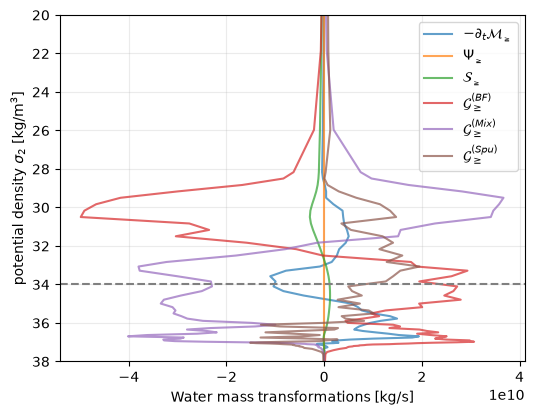

In [8]:
plt.figure(figsize=(6,4.5))

kwargs = {"alpha":0.7, "lw":1.5}

plt.plot(-wmt.mass_tendency,                wmt.sigma2_l_target, label=r"$-\partial_{t} \mathcal{M}_{_{\geq}}$",**kwargs)
plt.plot( 0.*wmt.sigma2_l_target,           wmt.sigma2_l_target, label=r"$\Psi_{_{\geq}}$",                   **kwargs)
plt.plot( wmt.mass_source,                  wmt.sigma2_l_target, label=r"$\mathcal{S}_{_{\geq}}$",            **kwargs)
plt.plot( wmt.boundary_fluxes,              wmt.sigma2_l_target, label=r"$\mathcal{G}^{(BF)}_{\geq}$",      **kwargs)
plt.plot( wmt.diffusion,                    wmt.sigma2_l_target, label=r"$\mathcal{G}^{(Mix)}_{\geq}$",     **kwargs)
plt.plot( wmt.spurious_numerical_mixing,    wmt.sigma2_l_target, label=r"$\mathcal{G}^{(Spu)}_{\geq}$", **kwargs)
plt.axhline(34, color="grey", linestyle="dashed")

plt.legend(loc="upper right")
plt.grid(True, alpha=0.25)
plt.ylabel(r"potential density $\sigma_{2}$ [kg/m$^{3}$]");
plt.xlabel("Water mass transformations [kg/s]")
plt.ylim(38, 20);

### Scientific Interpretation

Consider the mass budget for $\sigma_{2} = 34$ $\text{kg/m}^{3}$, highlighted by the dashed grey line in the figure above:

- Surface buoyancy loss (presumably at high latitudes) form dense waters at a rate of $\mathcal{G}^{(BF)}_{\geq} \simeq 2.5 \times 10^{10}$ kg/s.

- Interior mixing by various parameterized physical processes destroys dense waters at a rate of $\mathcal{G}^{(Mix)}_{\geq} \simeq 2.25 \times 10^{10}$ kg/s (by mixing them with lighter waters), nearly balancing the formation rate at the surface.

- A small amount of freshwater is directly added to dense water masses via surface mass fluxes, with a globally-integrated rate of $\mathcal{S}_{\geq} \simeq 10^{9}$ kg/s.

- Spurious numerical mixing associated with errors in the horizontal advection scheme or vertical advection scheme (Lagrangian remapping-regridding scheme) induce water mass transformations that are generally weaker than those due to parameterized mixing, but are not always of the same sign! We interpret the positive $\mathcal{G}^{(Spu)}_{\geq}$ at $\sigma_{2} = 34$ $\text{kg/m}^{3}$ to reflect spurious numerical entrainment in the overflows associated with North Atlantic Deep Water formation.

- The sum of dense water formation by surface buoyancy fluxes and spurious numerical entrainment is much larger than the rate of destruction by parameterized interior mixing, resulting in an imbalance that causes the mass of dense water to increase at a rate of $\partial_{t} \mathcal{M}_{\geq} \simeq 10^{10}$ kg/s.


### On the attribution of the residual to spurious numerical mixing

While we have here interpreted the residual water mass transformations implied by the non-closure of the water mass budget as spurious numerical mixing, it is possible. However, in [Drake et al. (2025)](https://doi.org/10.1029/2024MS004383) we have performed sensitivity experiments to test several alternative error sources and found them to be either small or random, such that they can not explain the leading-order structure shown in the budget above.


## 2. Regional water mass budgets

### Example 1: specifying a region by its boundary

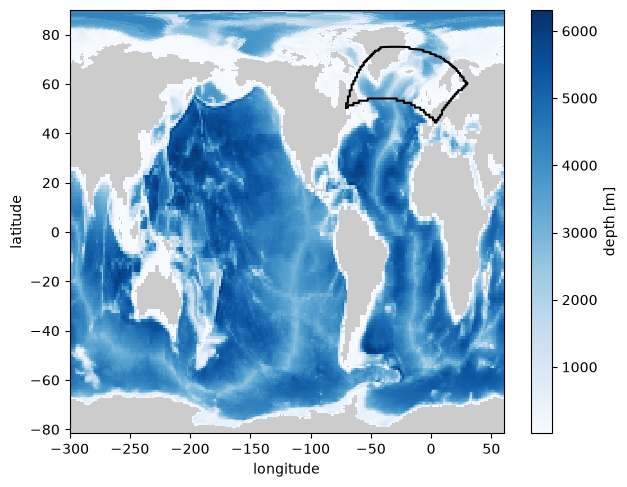

In [9]:
# Note: the properties of this region are quite different from the rest of the Baltic!
name = "North Atlantic"
lons = np.array([-70, -40,  30,   5])
lats = np.array([ 50,  75,  60,  44])
# regionate/sectionate trace a boundary by padding corner-index arrays over
# every axis the grid registers, so they need a horizontal-only view of it --
# a Z axis those 2-D arrays do not span makes xgcm's `pad` raise. (Passing
# `(lons, lats)` straight to `WaterMassBudget` does this for you; here we want
# the `GriddedRegion` itself, to plot its boundary.)
region = regionate.GriddedRegion(name, lons, lats, xwmb.horizontal_grid(grid))

plt.figure(figsize=(7,5.5))
plt.subplot(facecolor=(0.8, 0.8, 0.8))
pc = plt.pcolor(
    grid._ds['geolon_c'],
    grid._ds['geolat_c'],
    grid._ds['deptho'].where(grid._ds['deptho']!=0),
    cmap="Blues",
)
plt.colorbar(pc, label="depth [m]")
plt.plot(region.lons_c, region.lats_c, color="k");
plt.xlabel("longitude");
plt.ylabel("latitude");

In [10]:
lam = "sigma2"
wmb = xwmb.WaterMassBudget(
    grid,
    recipe,
    region  # specify the region
)
wmb.mass_budget(lam, greater_than=True)
wmt = wmb.wmt.squeeze()
wmt.load()

<xarray.Dataset> Size: 26kB
Dimensions:                                         (sigma2_l_target: 74,
                                                     bnds: 2,
                                                     sigma2_i_target: 75,
                                                     time_bounds: 2)
Coordinates:
  * sigma2_l_target                                 (sigma2_l_target) float64 592B ...
  * sigma2_i_target                                 (sigma2_i_target) float64 600B ...
  * time_bounds                                     (time_bounds) object 16B ...
    time_bounds_since_init                          (time_bounds) object 16B ...
    time                                            object 8B 2000-07-01 00:0...
Dimensions without coordinates: bnds
Data variables: (12/41)
    Eulerian_tendency_heat                          (sigma2_l_target) float64 592B ...
    Eulerian_tendency_salt                          (sigma2_l_target) float64 592B ...
    advection_heat                                  (sigma2_l_target) float64 592B ...
    advection_salt                                  (sigma2_l_target) float64 592B ...
    surface_exchange_flux_heat                      (sigma2_l_target) float64 592B ...
    surface_exchange_flux_salt                      (sigma2_l_target) float64 592B ...
    ...                                              ...
    dt                                              float64 8B 3.154e+07
    realized_transformation                         (sigma2_l_target) float64 592B ...
    residual                                        (sigma2_l_target) float64 592B ...
    spurious_numerical_mixing                       (sigma2_l_target) float64 592B ...
    advection_plus_BC                               (sigma2_l_target) float64 592B ...
    diabatic_advection                              (sigma2_l_target) float64 592B ...
Attributes:
    title:           Water mass transformation rates across sigma2 surfaces
    comment:         xwmt does not check that mass or tracers are conserved. ...
    references:      Walin, G. (1982), doi:10.1111/j.2153-3490.1982.tb01806.x...
    source:          xwmt 0.3.0rc1 (https://github.com/NOAA-GFDL/xwmt)
    xwmt_version:    0.3.0rc1
    xwmt_lambda:     sigma2
    xwmt_method:     xgcm
    xwmt_integrate:  true

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
/var/folders/bx/qc2zqzmj6fn43b6pscs_6hsc0000gn/T/ipykernel_16864/4027933490.py:11: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(wmt.convergent_mass_transport.idxmin(), color="grey", linestyle="dashed", label="$\sigma_{2}$ of $\min(\Psi_{\geq})$ (AMOC)")


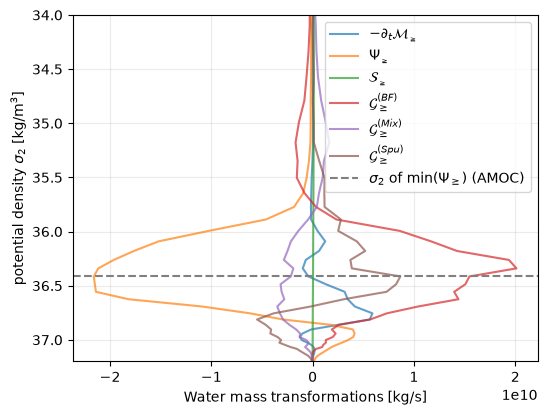

In [11]:
plt.figure(figsize=(6,4.5))

kwargs = {"alpha":0.7, "lw":1.5}

plt.plot(-wmt.mass_tendency,                wmt.sigma2_l_target, label=r"$-\partial_{t} \mathcal{M}_{_{\geq}}$",**kwargs)
plt.plot( wmt.convergent_mass_transport,    wmt.sigma2_l_target, label=r"$\Psi_{_{\geq}}$",                   **kwargs)
plt.plot( wmt.mass_source,                  wmt.sigma2_l_target, label=r"$\mathcal{S}_{_{\geq}}$",            **kwargs)
plt.plot( wmt.boundary_fluxes,              wmt.sigma2_l_target, label=r"$\mathcal{G}^{(BF)}_{\geq}$",      **kwargs)
plt.plot( wmt.diffusion,                    wmt.sigma2_l_target, label=r"$\mathcal{G}^{(Mix)}_{\geq}$",     **kwargs)
plt.plot( wmt.spurious_numerical_mixing,    wmt.sigma2_l_target, label=r"$\mathcal{G}^{(Spu)}_{\geq}$", **kwargs)
plt.axhline(wmt.convergent_mass_transport.idxmin(), color="grey", linestyle="dashed", label="$\sigma_{2}$ of $\min(\Psi_{\geq})$ (AMOC)")

plt.legend(loc="upper right")
plt.grid(True, alpha=0.25)
plt.ylabel(r"potential density $\sigma_{2}$ [kg/m$^{3}$]");
plt.xlabel("Water mass transformations [kg/s]")
plt.ylim(37.2, 34);

### Example 2: specifying a region by its interior mask

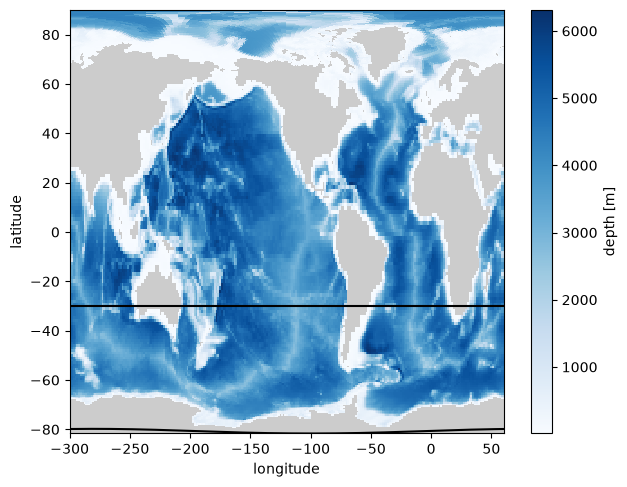

In [12]:
name = "Southern Ocean"
mask = grid._ds.geolat < -30.

# regionate 0.6 splits a mask into topology-aware connected components, and each
# component's boundary is a *list* of `sectionate.GriddedSection` loops -- a region
# straddling a tripolar fold or a tile seam legitimately has more than one.
regions = regionate.MaskRegions(mask, xwmb.horizontal_grid(grid), name)
region = regions.region_dict[0]  # here the mask is a single contiguous component

plt.figure(figsize=(7,5.5))
plt.subplot(facecolor=(0.8, 0.8, 0.8))
pc = plt.pcolor(
    grid._ds['geolon_c'],
    grid._ds['geolat_c'],
    grid._ds['deptho'].where(grid._ds['deptho']!=0),
    cmap="Blues",
)
plt.colorbar(pc, label="depth [m]")
for loop in region.boundaries:
    plt.plot(loop.lons_c, loop.lats_c, color="k")
plt.xlabel("longitude");
plt.ylabel("latitude");

In [13]:
lam = "sigma2"
wmb = xwmb.WaterMassBudget(
    grid,
    recipe,
    region  # specify the region
)
wmb.mass_budget(lam, greater_than=True)
wmt = wmb.wmt.squeeze()
wmt.load()

<xarray.Dataset> Size: 26kB
Dimensions:                                         (sigma2_l_target: 74,
                                                     bnds: 2,
                                                     sigma2_i_target: 75,
                                                     time_bounds: 2)
Coordinates:
  * sigma2_l_target                                 (sigma2_l_target) float64 592B ...
  * sigma2_i_target                                 (sigma2_i_target) float64 600B ...
  * time_bounds                                     (time_bounds) object 16B ...
    time_bounds_since_init                          (time_bounds) object 16B ...
    time                                            object 8B 2000-07-01 00:0...
Dimensions without coordinates: bnds
Data variables: (12/41)
    Eulerian_tendency_heat                          (sigma2_l_target) float64 592B ...
    Eulerian_tendency_salt                          (sigma2_l_target) float64 592B ...
    advection_heat                                  (sigma2_l_target) float64 592B ...
    advection_salt                                  (sigma2_l_target) float64 592B ...
    surface_exchange_flux_heat                      (sigma2_l_target) float64 592B ...
    surface_exchange_flux_salt                      (sigma2_l_target) float64 592B ...
    ...                                              ...
    dt                                              float64 8B 3.154e+07
    realized_transformation                         (sigma2_l_target) float64 592B ...
    residual                                        (sigma2_l_target) float64 592B ...
    spurious_numerical_mixing                       (sigma2_l_target) float64 592B ...
    advection_plus_BC                               (sigma2_l_target) float64 592B ...
    diabatic_advection                              (sigma2_l_target) float64 592B ...
Attributes:
    title:           Water mass transformation rates across sigma2 surfaces
    comment:         xwmt does not check that mass or tracers are conserved. ...
    references:      Walin, G. (1982), doi:10.1111/j.2153-3490.1982.tb01806.x...
    source:          xwmt 0.3.0rc1 (https://github.com/NOAA-GFDL/xwmt)
    xwmt_version:    0.3.0rc1
    xwmt_lambda:     sigma2
    xwmt_method:     xgcm
    xwmt_integrate:  true

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:14: SyntaxWarning: invalid escape sequence '\s'
/var/folders/bx/qc2zqzmj6fn43b6pscs_6hsc0000gn/T/ipykernel_16864/3791978204.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(sigma2_amoc, color="grey", linestyle="dashed", label="$\sigma_{2}$ of $\max(\Psi_{\geq})$ (AMOC)")
/var/folders/bx/qc2zqzmj6fn43b6pscs_6hsc0000gn/T/ipykernel_16864/3791978204.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(sigma2_smoc, color="grey", linestyle="dotted", label="$\sigma_{2}$ of $\max(\Psi_{\geq})$ (SMOC)")


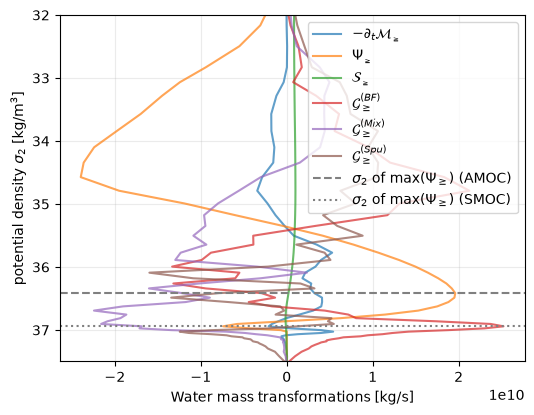

In [14]:
plt.figure(figsize=(6,4.5))

kwargs = {"alpha":0.7, "lw":1.5}

plt.plot(-wmt.mass_tendency,                wmt.sigma2_l_target, label=r"$-\partial_{t} \mathcal{M}_{_{\geq}}$",**kwargs)
plt.plot( wmt.convergent_mass_transport,    wmt.sigma2_l_target, label=r"$\Psi_{_{\geq}}$",                   **kwargs)
plt.plot( wmt.mass_source,                  wmt.sigma2_l_target, label=r"$\mathcal{S}_{_{\geq}}$",            **kwargs)
plt.plot( wmt.boundary_fluxes,              wmt.sigma2_l_target, label=r"$\mathcal{G}^{(BF)}_{\geq}$",      **kwargs)
plt.plot( wmt.diffusion,                    wmt.sigma2_l_target, label=r"$\mathcal{G}^{(Mix)}_{\geq}$",     **kwargs)
plt.plot( wmt.spurious_numerical_mixing,    wmt.sigma2_l_target, label=r"$\mathcal{G}^{(Spu)}_{\geq}$", **kwargs)
sigma2_amoc = wmt.convergent_mass_transport.idxmax().compute()
sigma2_smoc = wmt.convergent_mass_transport.sel(sigma2_l_target=slice(sigma2_amoc, None)).idxmin().compute()
plt.axhline(sigma2_amoc, color="grey", linestyle="dashed", label="$\sigma_{2}$ of $\max(\Psi_{\geq})$ (AMOC)")
plt.axhline(sigma2_smoc, color="grey", linestyle="dotted", label="$\sigma_{2}$ of $\max(\Psi_{\geq})$ (SMOC)")


plt.legend(loc="upper right")
plt.grid(True, alpha=0.25)
plt.ylabel(r"potential density $\sigma_{2}$ [kg/m$^{3}$]");
plt.xlabel("Water mass transformations [kg/s]")
plt.ylim(37.5, 32);

## 3. More granular control over transformation budgets

We now repeat the same calculation, with the only differences being that we use the following two keyword arguments to further break down the budget.

### Example 1. Decomposing surface heat flux contributions

To decompose the nonadvective surface transformations by term, we pass `decompose = ["surface_exchange_flux", "nonadvective"]` to `xwmb.WaterMassBudget`

In [15]:
lam = "sigma2"
wmb = xwmb.WaterMassBudget(
    grid,
    recipe,
    region,
    decompose=["surface_exchange_flux", "nonadvective"]
)
wmb.mass_budget(lam, greater_than=True)
wmt = wmb.wmt.squeeze()
wmt.load()

<xarray.Dataset> Size: 32kB
Dimensions:                                            (sigma2_l_target: 74,
                                                        bnds: 2,
                                                        sigma2_i_target: 75,
                                                        time_bounds: 2)
Coordinates:
  * sigma2_l_target                                    (sigma2_l_target) float64 592B ...
  * sigma2_i_target                                    (sigma2_i_target) float64 600B ...
  * time_bounds                                        (time_bounds) object 16B ...
    time_bounds_since_init                             (time_bounds) object 16B ...
    time                                               object 8B 2000-07-01 0...
Dimensions without coordinates: bnds
Data variables: (12/51)
    Eulerian_tendency_heat                             (sigma2_l_target) float64 592B ...
    Eulerian_tendency_salt                             (sigma2_l_target) float64 592B ...
    advection_heat                                     (sigma2_l_target) float64 592B ...
    advection_salt                                     (sigma2_l_target) float64 592B ...
    surface_ocean_flux_advective_negative_lhs_heat     (sigma2_l_target) float64 592B ...
    surface_ocean_flux_advective_negative_lhs_salt     (sigma2_l_target) float64 592B ...
    ...                                                 ...
    dt                                                 float64 8B 3.154e+07
    realized_transformation                            (sigma2_l_target) float64 592B ...
    residual                                           (sigma2_l_target) float64 592B ...
    spurious_numerical_mixing                          (sigma2_l_target) float64 592B ...
    advection_plus_BC                                  (sigma2_l_target) float64 592B ...
    diabatic_advection                                 (sigma2_l_target) float64 592B ...
Attributes:
    title:           Water mass transformation rates across sigma2 surfaces
    comment:         xwmt does not check that mass or tracers are conserved. ...
    references:      Walin, G. (1982), doi:10.1111/j.2153-3490.1982.tb01806.x...
    source:          xwmt 0.3.0rc1 (https://github.com/NOAA-GFDL/xwmt)
    xwmt_version:    0.3.0rc1
    xwmt_lambda:     sigma2
    xwmt_method:     xgcm
    xwmt_integrate:  true

<>:19: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\s'
/var/folders/bx/qc2zqzmj6fn43b6pscs_6hsc0000gn/T/ipykernel_16864/2597396747.py:19: SyntaxWarning: invalid escape sequence '\s'
  plt.axhline(sigma2_smoc, color="grey", linestyle="dotted", label="$\sigma_{2}$ of $\max(\Psi_{\geq})$ (SMOC)")


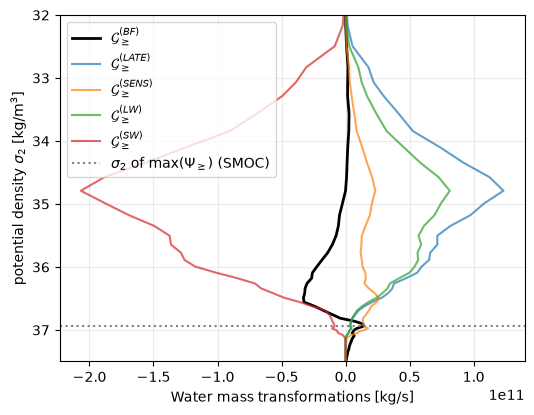

In [16]:
plt.figure(figsize=(6,4.5))

kwargs = {"alpha":0.7, "lw":1.5}

plt.plot( wmt.boundary_fluxes,              wmt.sigma2_l_target, label=r"$\mathcal{G}^{(BF)}_{\geq}$", color="k", lw=2)

# Plot transformations due to each contributing heat flux term
heat_fluxes = ["latent", "sensible", "longwave", "shortwave"]
heat_flux_dict = {
    heat_flux: f"surface_exchange_flux_nonadvective_{heat_flux}_heat"
    for heat_flux in heat_fluxes
}
plt.plot( wmt[heat_flux_dict["latent"]],              wmt.sigma2_l_target, label=r"$\mathcal{G}^{(LATE)}_{\geq}$",      **kwargs)
plt.plot( wmt[heat_flux_dict["sensible"]],              wmt.sigma2_l_target, label=r"$\mathcal{G}^{(SENS)}_{\geq}$",      **kwargs)
plt.plot( wmt[heat_flux_dict["longwave"]],              wmt.sigma2_l_target, label=r"$\mathcal{G}^{(LW)}_{\geq}$",      **kwargs)
plt.plot( wmt[heat_flux_dict["shortwave"]],              wmt.sigma2_l_target, label=r"$\mathcal{G}^{(SW)}_{\geq}$",      **kwargs)

sigma2_smoc = wmt.convergent_mass_transport.sel(sigma2_l_target=slice(sigma2_amoc, None)).idxmin().compute()
plt.axhline(sigma2_smoc, color="grey", linestyle="dotted", label="$\sigma_{2}$ of $\max(\Psi_{\geq})$ (SMOC)")


plt.legend(loc="upper left")
plt.grid(True, alpha=0.25)
plt.ylabel(r"potential density $\sigma_{2}$ [kg/m$^{3}$]");
plt.xlabel("Water mass transformations [kg/s]")
plt.ylim(37.5, 32);

### Example 2. Spatial patterns

To compute spatial patterns of transformation rates, rather than the default of area-integrating, we pass `integrate=False` to `xwmb.WaterMassBudgetmass_budget`.

In [17]:
lam = "sigma2"
wmb = xwmb.WaterMassBudget(
    grid,
    recipe,
    region,
    decompose=["surface_exchange_flux", "nonadvective"]
)
wmb.mass_budget(lam, greater_than=True, integrate=False)
wmt = wmb.wmt.squeeze()
wmt.load()

/opt/anaconda3/envs/xwmb-070/lib/python3.12/site-packages/xwmt/wmt.py:1099: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  merged = xr.merge(wmts)
/opt/anaconda3/envs/xwmb-070/lib/python3.12/site-packages/xwmt/wmt.py:1099: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  merged = xr.merge(wmts)
/opt/anaconda3/envs/xwmb-070/lib/python3.12/

/opt/anaconda3/envs/xwmb-070/lib/python3.12/site-packages/xwmt/wmt.py:1099: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  merged = xr.merge(wmts)
/opt/anaconda3/envs/xwmb-070/lib/python3.12/site-packages/xwmt/wmt.py:1099: FutureWarning: In a future version of xarray the default value for compat will change from compat='no_conflicts' to compat='override'. This is likely to lead to different results when combining overlapping variables with the same name. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set compat explicitly.
  merged = xr.merge(wmts)


<xarray.Dataset> Size: 1GB
Dimensions:                                            (yh: 180, xh: 240,
                                                        sigma2_l_target: 74,
                                                        bnds: 2,
                                                        sigma2_i_target: 75,
                                                        time_bounds: 2)
Coordinates: (12/14)
  * yh                                                 (yh) int64 1kB 0 ... 179
  * xh                                                 (xh) int64 2kB 0 ... 239
    areacello                                          (yh, xh) float64 346kB ...
    deptho                                             (yh, xh) float32 173kB ...
    geolat                                             (yh, xh) float64 346kB ...
    geolon                                             (yh, xh) float64 346kB ...
    ...                                                 ...
    wet                                                (yh, xh) float32 173kB ...
  * sigma2_l_target                                    (sigma2_l_target) float64 592B ...
  * sigma2_i_target                                    (sigma2_i_target) float64 600B ...
  * time_bounds                                        (time_bounds) object 16B ...
    time_bounds_since_init                             (time_bounds) object 16B ...
    time                                               object 8B 2000-07-01 0...
Dimensions without coordinates: bnds
Data variables: (12/51)
    Eulerian_tendency_heat                             (yh, xh, sigma2_l_target) float64 26MB ...
    Eulerian_tendency_salt                             (yh, xh, sigma2_l_target) float64 26MB ...
    advection_heat                                     (yh, xh, sigma2_l_target) float64 26MB ...
    advection_salt                                     (yh, xh, sigma2_l_target) float64 26MB ...
    surface_ocean_flux_advective_negative_lhs_heat     (yh, xh, sigma2_l_target) float64 26MB ...
    surface_ocean_flux_advective_negative_lhs_salt     (yh, xh, sigma2_l_target) float64 26MB ...
    ...                                                 ...
    dt                                                 float64 8B 3.154e+07
    realized_transformation                            (yh, xh, sigma2_l_target) float64 26MB ...
    residual                                           (yh, xh, sigma2_l_target) float64 26MB ...
    spurious_numerical_mixing                          (yh, xh, sigma2_l_target) float64 26MB ...
    advection_plus_BC                                  (yh, xh, sigma2_l_target) float64 26MB ...
    diabatic_advection                                 (yh, xh, sigma2_l_target) float64 26MB ...
Attributes:
    title:           Water mass transformation rates across sigma2 surfaces
    comment:         xwmt does not check that mass or tracers are conserved. ...
    references:      Walin, G. (1982), doi:10.1111/j.2153-3490.1982.tb01806.x...
    source:          xwmt 0.3.0rc1 (https://github.com/NOAA-GFDL/xwmt)
    xwmt_version:    0.3.0rc1
    xwmt_lambda:     sigma2
    xwmt_method:     xgcm
    xwmt_integrate:  false

Supposing we are interested in how these fluxes contribute to the formation of dense waters, we select the isopycnal of maximum SMOC transport.

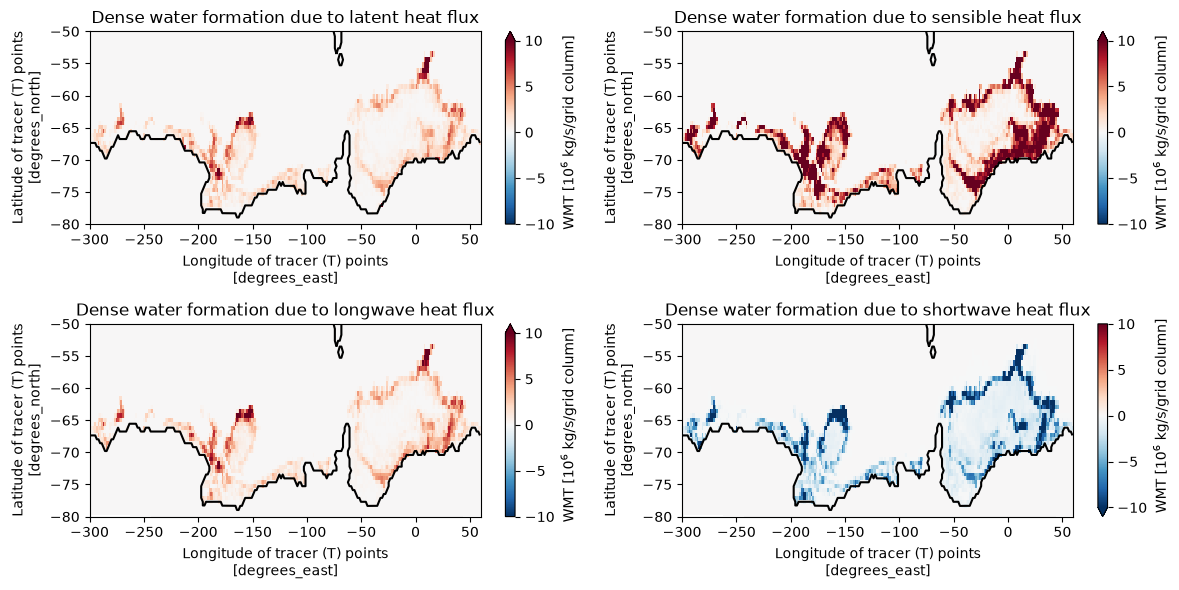

In [18]:
def plot_smoc_transformation_map(term, ax):
    pc = (wmt[heat_flux_dict[term]]*1e-6).sel(sigma2_l_target=sigma2_smoc).plot(
        ax=ax, x="geolon", y="geolat",
        cmap="RdBu_r", vmin=-10, vmax=10
    )
    (grid._ds.wet == 0).plot.contour(ax=ax, x="geolon", y="geolat", colors="k", levels=[0])
    pc.colorbar.set_label(r"WMT [10$^{6}$ kg/s/grid column]")
    ax.set_title(f"Dense water formation due to {term} heat flux")
    ax.set_ylim(-80, -50)

fig, axes = plt.subplots(2,2, figsize=(12, 6))
for ax, term in zip(axes.flatten(), heat_flux_dict.keys()):
    plot_smoc_transformation_map(term, ax)
plt.tight_layout()